# What Makes a Society Healthy?

## A Machine Learning Analysis of Life Expectancy Across Countries

## 1. Objective and Research Question

### Research Question

Which economic, healthcare, lifestyle, environmental and social factors best explain differences in life expectancy across countries?

### Objective

The objective of this project is to analyze the determinants of life expectancy across countries using international datasets and machine learning methods.

The project compares different groups of explanatory variables, including economic development, healthcare spending, lifestyle risk factors, environmental exposure and social indicators.

The goal is not only to build a predictive model, but also to understand which macro-categories of variables are most informative in explaining cross-country differences in life expectancy.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

## 2. Data Sources and Variable Framework

The analysis uses country-level international data from public sources, mainly World Bank indicators and World Bank Data360 health-related data.

The target variable is:

- **Life expectancy at birth**

The explanatory variables are organized into five macro-categories:

1. **Economic Factors**
   - GDP per capita

2. **Healthcare Factors**
   - Health expenditure as a percentage of GDP
   - Health expenditure per capita

3. **Lifestyle Factors**
   - Obesity prevalence
   - Smoking prevalence

4. **Environmental Factors**
   - PM2.5 air pollution

5. **Social Factors**
   - Education

Most variables refer to 2022. However, PM2.5 air pollution data were not available for 2022 in the selected indicator, so 2020 PM2.5 exposure was used as the most recent available environmental proxy with broad country coverage.

The project tests both relative healthcare spending and absolute healthcare spending in order to evaluate which measure is more informative for predicting life expectancy.

## 3. Loading Final Project Outputs

The full exploratory workflow, including intermediate tests and experiments, is preserved in the working notebook.

This final notebook focuses on the cleaned datasets, model audit tables, feature importance results and final visualizations used to support the final interpretation of the project.

In [23]:
base_dataset = pd.read_csv("../data/life_expectancy_dataset_v2.csv")
model_audit = pd.read_csv("../data/model_audit.csv")
model_comparison = pd.read_csv("../data/model_comparison.csv")
rf_performance_audit = pd.read_csv("../data/random_forest_performance_audit.csv")
feature_importance_audit = pd.read_csv("../data/feature_importance_audit.csv")
final_model_dataset = pd.read_csv("../data/final_absolute_healthcare_environment_model_dataset.csv")
final_m9_importance = pd.read_csv("../data/final_absolute_healthcare_environment_feature_importance.csv")

print("Base dataset shape:", base_dataset.shape)
print("Final model dataset shape:", final_model_dataset.shape)
print("Model audit shape:", model_audit.shape)
print("Random Forest performance audit shape:", rf_performance_audit.shape)
print("Feature importance audit shape:", feature_importance_audit.shape)

Base dataset shape: (212, 6)
Final model dataset shape: (155, 9)
Model audit shape: (9, 9)
Random Forest performance audit shape: (7, 6)
Feature importance audit shape: (26, 4)


## 4. Data Quality Audit

Before interpreting the results, the final project files are checked for consistency.

The audit focuses on:

- dataset dimensions;
- missing values;
- potential aggregate observations;
- implausible life expectancy values;
- consistency between model comparison files;
- feature importance validity.

In [24]:
print("Base dataset columns:")
print(base_dataset.columns.tolist())

print("\nFinal model dataset columns:")
print(final_model_dataset.columns.tolist())

print("\nModel audit columns:")
print(model_audit.columns.tolist())

print("\nFeature importance audit columns:")
print(feature_importance_audit.columns.tolist())

Base dataset columns:
['country_code', 'country', 'year', 'life_expectancy', 'gdp_per_capita', 'health_expenditure']

Final model dataset columns:
['country_code', 'country', 'life_expectancy', 'gdp_per_capita', 'health_expenditure', 'obesity', 'smoking', 'air_pollution', 'health_expenditure_per_capita']

Model audit columns:
['Model_ID', 'Model_name', 'Algorithm', 'Macro_categories', 'Variables_used', 'Observations', 'R_squared', 'MAE_years', 'Notes']

Feature importance audit columns:
['Model_ID', 'Model_name', 'Feature', 'Importance']


### Missing Values

The base dataset still contains some missing values because it includes variables before model-specific filtering.

Each model-specific dataset was created by dropping observations with missing values for the variables required by that model.

The final M9 dataset contains no missing values across the selected predictors.

In [25]:
print("Missing values - base dataset")
display(base_dataset.isna().sum().to_frame("missing_values"))

print("\nMissing values - final model dataset")
display(final_model_dataset.isna().sum().to_frame("missing_values"))

print("\nMissing values - model audit")
display(model_audit.isna().sum().to_frame("missing_values"))

print("\nMissing values - feature importance audit")
display(feature_importance_audit.isna().sum().to_frame("missing_values"))

Missing values - base dataset


,missing_values
country_code,0
country,0
year,0
life_expectancy,0
gdp_per_capita,0
health_expenditure,21



Missing values - final model dataset


,missing_values
country_code,0
country,0
life_expectancy,0
gdp_per_capita,0
health_expenditure,0
obesity,0
smoking,0
air_pollution,0
health_expenditure_per_capita,0



Missing values - model audit


,missing_values
Model_ID,0
Model_name,0
Algorithm,0
Macro_categories,0
Variables_used,0
Observations,0
R_squared,0
MAE_years,0
Notes,0



Missing values - feature importance audit


,missing_values
Model_ID,0
Model_name,0
Feature,0
Importance,0


### Aggregate Observations Check

The initial merged dataset may contain some World Bank aggregate groups, such as regional or income-level groups.

Since the objective is to analyze cross-country differences, potential aggregate observations are checked explicitly.

The final modeling dataset should focus on country-level observations.

In [26]:
aggregate_keywords = [
    "World",
    "income",
    "IDA",
    "IBRD",
    "OECD",
    "Euro area",
    "Arab",
    "East Asia",
    "Europe",
    "Central Asia",
    "Latin America",
    "Caribbean",
    "Middle East",
    "North Africa",
    "South Asia",
    "Sub-Saharan",
    "Fragile",
    "demographic dividend",
    "Heavily indebted",
    "Small states",
    "Pacific island",
    "Least developed",
    "European Union",
    "Africa Eastern",
    "Africa Western"
]

pattern = "|".join(aggregate_keywords)

base_aggregate_check = base_dataset[
    base_dataset["country"].str.contains(pattern, case=False, na=False)
]

final_aggregate_check = final_model_dataset[
    final_model_dataset["country"].str.contains(pattern, case=False, na=False)
]

print("Potential aggregate observations in base dataset:", len(base_aggregate_check))
display(base_aggregate_check[["country_code", "country"]])

print("\nPotential aggregate observations in final model dataset:", len(final_aggregate_check))
display(final_aggregate_check[["country_code", "country"]])

Potential aggregate observations in base dataset: 10


,country_code,country
0,EAR,Early-demographic dividend
1,EAS,East Asia & Pacific
2,FCS,Fragile and conflict affected situations
3,HPC,Heavily indebted poor countries (HIPC)
4,LTE,Late-demographic dividend
5,LCN,Latin America & Caribbean
6,LDC,Least developed countries: UN classification
8,PST,Post-demographic dividend
9,PRE,Pre-demographic dividend
10,SAS,South Asia



Potential aggregate observations in final model dataset: 0


,country_code,country


The audit shows that the base dataset still contains a small number of potential World Bank aggregate groups.

However, the final model dataset contains no detected aggregate observations according to the keyword-based aggregate check used in this notebook.

### Life Expectancy Anomaly Check

The cleaned datasets are checked for implausible life expectancy values.

No observations below 40 years remain in either the base dataset or the final M9 dataset.

In [27]:
print("Life expectancy summary - base dataset")
display(base_dataset["life_expectancy"].describe())

print("\nLife expectancy summary - final model dataset")
display(final_model_dataset["life_expectancy"].describe())

print("\nBase dataset observations with life expectancy < 40")
display(
    base_dataset[
        base_dataset["life_expectancy"] < 40
    ][["country_code", "country", "year", "life_expectancy"]]
)

print("\nFinal model dataset observations with life expectancy < 40")
display(
    final_model_dataset[
        final_model_dataset["life_expectancy"] < 40
    ][["country_code", "country", "life_expectancy"]]
)

Life expectancy summary - base dataset


count    212.000000
mean      73.236561
std        7.055553
min       53.931000
25%       67.638250
50%       74.238000
75%       78.284250
max       85.746000
Name: life_expectancy, dtype: float64


Life expectancy summary - final model dataset


count    155.000000
mean      72.971255
std        7.032692
min       54.079000
25%       67.425500
50%       74.125000
75%       78.102500
max       84.016000
Name: life_expectancy, dtype: float64


Base dataset observations with life expectancy < 40


,country_code,country,year,life_expectancy



Final model dataset observations with life expectancy < 40


,country_code,country,life_expectancy


## 5. Final Model Dataset

The best-performing model is M9, which uses the following variables:

- Life expectancy
- GDP per capita
- Health expenditure per capita
- Obesity prevalence
- Smoking prevalence
- PM2.5 air pollution

The final model dataset contains 155 observations and no missing values across the selected predictors.

In [29]:
m9_expected_columns = [
    "country_code",
    "country",
    "life_expectancy",
    "gdp_per_capita",
    "health_expenditure_per_capita",
    "obesity",
    "smoking",
    "air_pollution"
]

print("Expected M9 columns present?")
for col in m9_expected_columns:
    print(col, "->", col in final_model_dataset.columns)

final_model_dataset[m9_expected_columns].head()

Expected M9 columns present?
country_code -> True
country -> True
life_expectancy -> True
gdp_per_capita -> True
health_expenditure_per_capita -> True
obesity -> True
smoking -> True
air_pollution -> True


,country_code,country,life_expectancy,gdp_per_capita,health_expenditure_per_capita,obesity,smoking,air_pollution
0,AFG,Afghanistan,65.617,357.261153,80.651604,19.222592,22.7,46.087094
1,ALB,Albania,78.769,7756.961887,506.869202,23.360185,21.9,15.707004
2,DZA,Algeria,76.129,4960.303343,180.334549,23.814993,21.2,25.552656
3,AND,Andorra,84.016,42414.047986,3190.113281,18.099177,36.3,9.080281
4,ARG,Argentina,75.806,13962.189409,1415.795776,35.355195,23.8,14.908174


In [30]:
final_model_dataset[m9_expected_columns].describe().round(3)

,life_expectancy,gdp_per_capita,health_expenditure_per_capita,obesity,smoking,air_pollution
count,155.000,155.000,155.000,155.000,155.000,155.000
mean,72.971,17368.051,1374.840,22.532,19.977,23.483
std,7.033,23826.468,2043.510,12.761,10.060,15.657
min,54.079,302.993,15.858,2.016,3.300,4.895
25%,67.426,2368.593,102.196,12.497,11.250,12.299
50%,74.125,6680.445,469.349,21.784,19.500,19.494
75%,78.102,21102.159,1642.432,29.637,27.450,28.613
max,84.016,123719.659,10930.140,71.650,48.300,85.122


## 6. Exploratory Data Analysis

The exploratory analysis examines the main relationships between life expectancy and the explanatory variables used in the final model.

The first focus is GDP per capita, because economic development is expected to be strongly associated with life expectancy.

The second focus is the logarithmic transformation of GDP per capita, which helps capture diminishing returns to income.

In [31]:
final_model_dataset[
    [
        "life_expectancy",
        "gdp_per_capita",
        "health_expenditure_per_capita",
        "obesity",
        "smoking",
        "air_pollution"
    ]
].describe().round(2)

,life_expectancy,gdp_per_capita,health_expenditure_per_capita,obesity,smoking,air_pollution
count,155.00,155.00,155.00,155.00,155.00,155.00
mean,72.97,17368.05,1374.84,22.53,19.98,23.48
std,7.03,23826.47,2043.51,12.76,10.06,15.66
min,54.08,302.99,15.86,2.02,3.30,4.90
25%,67.43,2368.59,102.20,12.50,11.25,12.30
50%,74.12,6680.45,469.35,21.78,19.50,19.49
75%,78.10,21102.16,1642.43,29.64,27.45,28.61
max,84.02,123719.66,10930.14,71.65,48.30,85.12


In [32]:
correlation_matrix = final_model_dataset[
    [
        "life_expectancy",
        "gdp_per_capita",
        "health_expenditure_per_capita",
        "obesity",
        "smoking",
        "air_pollution"
    ]
].corr()

correlation_matrix.round(3)

,life_expectancy,gdp_per_capita,health_expenditure_per_capita,obesity,smoking,air_pollution
life_expectancy,1.000,0.673,0.656,0.208,0.264,-0.480
gdp_per_capita,0.673,1.000,0.908,0.084,0.050,-0.340
health_expenditure_per_capita,0.656,0.908,1.000,0.039,0.098,-0.452
obesity,0.208,0.084,0.039,1.000,0.197,-0.283
smoking,0.264,0.050,0.098,0.197,1.000,-0.395
air_pollution,-0.480,-0.340,-0.452,-0.283,-0.395,1.000


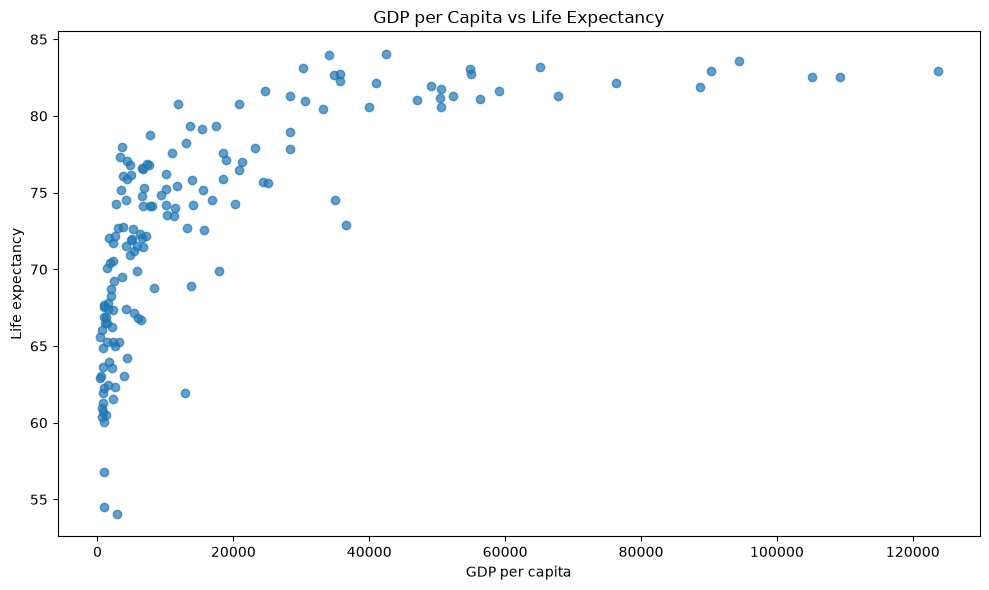

In [33]:
plt.figure(figsize=(10, 6))

plt.scatter(
    final_model_dataset["gdp_per_capita"],
    final_model_dataset["life_expectancy"],
    alpha=0.7
)

plt.title("GDP per Capita vs Life Expectancy")
plt.xlabel("GDP per capita")
plt.ylabel("Life expectancy")

plt.tight_layout()
plt.show()

The relationship between GDP per capita and life expectancy is positive but non-linear.

This suggests that increases in income are associated with higher life expectancy, but the marginal association appears stronger at lower income levels and weaker at higher income levels.

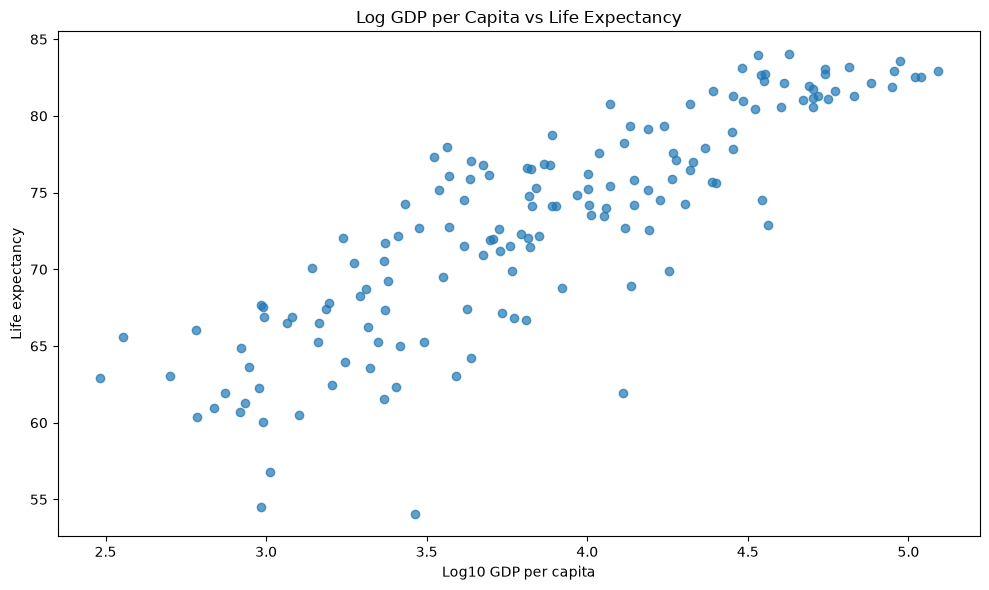

In [34]:
eda_dataset = final_model_dataset.copy()

eda_dataset = eda_dataset[
    eda_dataset["gdp_per_capita"] > 0
].copy()

eda_dataset["log_gdp_per_capita"] = np.log10(
    eda_dataset["gdp_per_capita"]
)

plt.figure(figsize=(10, 6))

plt.scatter(
    eda_dataset["log_gdp_per_capita"],
    eda_dataset["life_expectancy"],
    alpha=0.7
)

plt.title("Log GDP per Capita vs Life Expectancy")
plt.xlabel("Log10 GDP per capita")
plt.ylabel("Life expectancy")

plt.tight_layout()
plt.show()

The logarithmic transformation makes the relationship between GDP per capita and life expectancy more linear.

This supports the interpretation of diminishing returns to income: additional income is more strongly associated with life expectancy improvements in lower-income countries than in higher-income countries.

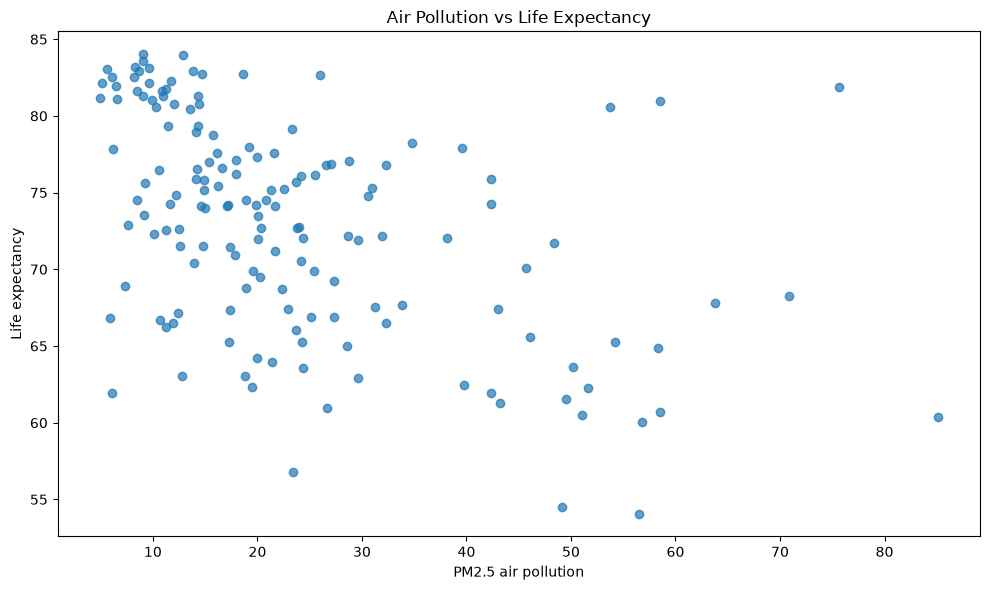

In [35]:
plt.figure(figsize=(10, 6))

plt.scatter(
    final_model_dataset["air_pollution"],
    final_model_dataset["life_expectancy"],
    alpha=0.7
)

plt.title("Air Pollution vs Life Expectancy")
plt.xlabel("PM2.5 air pollution")
plt.ylabel("Life expectancy")

plt.tight_layout()
plt.show()

Air pollution is included as an environmental factor.

The relationship between PM2.5 exposure and life expectancy is not interpreted causally, but the variable provides additional predictive information in the final Random Forest models.

## 7. Modeling Strategy

The modeling strategy follows a progressive structure.

The project starts with simple economic and healthcare baselines and then adds additional macro-categories step by step.

The models tested are:

- **M1:** Baseline Linear Regression using GDP per capita and health expenditure as % of GDP.
- **M2:** Log-GDP Linear Regression using log GDP per capita and health expenditure as % of GDP.
- **M3:** Baseline Random Forest using GDP per capita and health expenditure as % of GDP.
- **M4:** Social Extension Random Forest adding education.
- **M5:** Obesity Extension Random Forest adding obesity.
- **M6:** Lifestyle Extension Random Forest adding obesity and smoking.
- **M7:** Absolute Healthcare Spending Random Forest replacing health expenditure as % of GDP with health expenditure per capita.
- **M8:** Lifestyle & Environment Random Forest adding air pollution while using health expenditure as % of GDP.
- **M9:** Absolute Healthcare & Environment Random Forest using health expenditure per capita and air pollution.

Two model types are used:

1. **Linear Regression**, to provide interpretable baseline models.
2. **Random Forest Regression**, to capture non-linear relationships and compare feature importance.

The final model is selected based on predictive performance, sample size, interpretability and consistency with the project framework.

## 8. Model Audit: M1-M9

The following table summarizes all models tested in the project.

For models M3, M4, M5, M6 and M8, `health_expenditure` refers to health expenditure as a percentage of GDP.

For models M7 and M9, `health_expenditure_per_capita` refers to absolute healthcare spending per person.

In [37]:
model_audit

,Model_ID,Model_name,Algorithm,Macro_categories,Variables_used,Observations,R_squared,MAE_years,Notes
0,M1,Baseline Linear Regression,Linear Regression,"Economic, Relative Healthcare","gdp_per_capita, health_expenditure (% of GDP)",191,0.447,4.59,Baseline model using economic development and relative healthcare spending.
1,M2,Log-GDP Linear Regression,Linear Regression,"Economic, Relative Healthcare","log_gdp_per_capita, health_expenditure (% of GDP)",191,0.789,2.80,Tests diminishing returns of income by applying a logarithmic transformation to GDP per capita.
2,M3,Baseline Random Forest,Random Forest,"Economic, Relative Healthcare","gdp_per_capita, health_expenditure",191,0.757,2.75,Non-linear baseline model using the same variables as M1.
3,M4,Social Extension Random Forest,Random Forest,"Economic, Relative Healthcare, Social","gdp_per_capita, health_expenditure, education",107,0.630,2.58,Adds education as a social factor; sample size decreases substantially due to missing data.
4,M5,Obesity Extension Random Forest,Random Forest,"Economic, Relative Healthcare, Lifestyle","gdp_per_capita, health_expenditure, obesity",177,0.732,2.86,Adds obesity as the first lifestyle variable.
5,M6,Lifestyle Extension Random Forest,Random Forest,"Economic, Relative Healthcare, Lifestyle","gdp_per_capita, health_expenditure, obesity, smoking",155,0.802,2.77,Adds obesity and smoking; smoking improves predictive performance.
6,M7,Absolute Healthcare Spending Random Forest,Random Forest,"Economic, Absolute Healthcare, Lifestyle","gdp_per_capita, health_expenditure_per_capita, obesity, smoking",155,0.787,2.79,Replaces health expenditure as % of GDP with health expenditure per capita.
7,M8,Lifestyle & Environment Random Forest,Random Forest,"Economic, Relative Healthcare, Lifestyle, Environment","gdp_per_capita, health_expenditure, obesity, smoking, air_pollution",155,0.812,2.70,Adds PM2.5 air pollution using 2020 data as the most recent available environmental proxy.
8,M9,Absolute Healthcare & Environment Random Forest,Random Forest,"Economic, Absolute Healthcare, Lifestyle, Environment","gdp_per_capita, health_expenditure_per_capita, obesity, smoking, air_pollution",155,0.822,2.59,"Final candidate model combining economic development, absolute healthcare spending, lifestyle factors and air pollution."


### Model Audit Consistency Check

The model audit and model comparison files are checked for consistency.

In [38]:
print("model_audit equals model_comparison?")
print(model_audit.equals(model_comparison))

model_audit equals model_comparison?
True


## 9. Random Forest Performance Audit

The Random Forest models are compared using:

- R²
- Mean Absolute Error
- Number of observations
- Variables included

This comparison is important because some models achieve low prediction error on smaller samples, while others provide stronger explanatory performance on larger and more consistent samples.

In [40]:
rf_performance_audit

,Model_ID,Model_name,Observations,R_squared,MAE_years,Features
0,M3,Baseline Random Forest,191,0.757,2.75,"gdp_per_capita, health_expenditure"
1,M4,Social Extension Random Forest,107,0.630,2.58,"gdp_per_capita, health_expenditure, education"
2,M5,Obesity Extension Random Forest,177,0.732,2.86,"gdp_per_capita, health_expenditure, obesity"
3,M6,Lifestyle Extension Random Forest,155,0.802,2.77,"gdp_per_capita, health_expenditure, obesity, smoking"
4,M7,Absolute Healthcare Spending Random Forest,155,0.787,2.79,"gdp_per_capita, health_expenditure_per_capita, obesity, smoking"
5,M8,Lifestyle & Environment Random Forest,155,0.812,2.70,"gdp_per_capita, health_expenditure, obesity, smoking, air_pollution"
6,M9,Absolute Healthcare & Environment Random Forest,155,0.822,2.59,"gdp_per_capita, health_expenditure_per_capita, obesity, smoking, air_pollution"


In [41]:
rf_performance_audit.sort_values("R_squared", ascending=False)

,Model_ID,Model_name,Observations,R_squared,MAE_years,Features
6,M9,Absolute Healthcare & Environment Random Forest,155,0.822,2.59,"gdp_per_capita, health_expenditure_per_capita, obesity, smoking, air_pollution"
5,M8,Lifestyle & Environment Random Forest,155,0.812,2.70,"gdp_per_capita, health_expenditure, obesity, smoking, air_pollution"
3,M6,Lifestyle Extension Random Forest,155,0.802,2.77,"gdp_per_capita, health_expenditure, obesity, smoking"
4,M7,Absolute Healthcare Spending Random Forest,155,0.787,2.79,"gdp_per_capita, health_expenditure_per_capita, obesity, smoking"
0,M3,Baseline Random Forest,191,0.757,2.75,"gdp_per_capita, health_expenditure"
2,M5,Obesity Extension Random Forest,177,0.732,2.86,"gdp_per_capita, health_expenditure, obesity"
1,M4,Social Extension Random Forest,107,0.630,2.58,"gdp_per_capita, health_expenditure, education"


In [42]:
rf_performance_audit.sort_values("MAE_years", ascending=True)

,Model_ID,Model_name,Observations,R_squared,MAE_years,Features
1,M4,Social Extension Random Forest,107,0.630,2.58,"gdp_per_capita, health_expenditure, education"
6,M9,Absolute Healthcare & Environment Random Forest,155,0.822,2.59,"gdp_per_capita, health_expenditure_per_capita, obesity, smoking, air_pollution"
5,M8,Lifestyle & Environment Random Forest,155,0.812,2.70,"gdp_per_capita, health_expenditure, obesity, smoking, air_pollution"
0,M3,Baseline Random Forest,191,0.757,2.75,"gdp_per_capita, health_expenditure"
3,M6,Lifestyle Extension Random Forest,155,0.802,2.77,"gdp_per_capita, health_expenditure, obesity, smoking"
4,M7,Absolute Healthcare Spending Random Forest,155,0.787,2.79,"gdp_per_capita, health_expenditure_per_capita, obesity, smoking"
2,M5,Obesity Extension Random Forest,177,0.732,2.86,"gdp_per_capita, health_expenditure, obesity"


M9 has the highest R² among the Random Forest models.

M4 has a slightly lower MAE, but it is based on a much smaller sample and has substantially lower R².

For this reason, M9 is selected as the strongest final model candidate.

## 10. Feature Importance Analysis

Feature importance is used to understand which variables contribute most to each Random Forest model.

This section compares feature importance across all Random Forest models and then focuses on the final model, M9.

In [43]:
feature_importance_audit.sort_values(
    by=["Model_ID", "Importance"],
    ascending=[True, False]
)

,Model_ID,Model_name,Feature,Importance
0,M3,Baseline Random Forest,gdp_per_capita,0.832213
1,M3,Baseline Random Forest,health_expenditure,0.167787
2,M4,Social Extension Random Forest,gdp_per_capita,0.661767
3,M4,Social Extension Random Forest,education,0.294693
4,M4,Social Extension Random Forest,health_expenditure,0.043540
5,M5,Obesity Extension Random Forest,gdp_per_capita,0.807329
6,M5,Obesity Extension Random Forest,health_expenditure,0.096621
7,M5,Obesity Extension Random Forest,obesity,0.096050
8,M6,Lifestyle Extension Random Forest,gdp_per_capita,0.784144
9,M6,Lifestyle Extension Random Forest,smoking,0.093903


In [44]:
importance_sums = feature_importance_audit.groupby("Model_ID")["Importance"].sum()

print("Feature importance sums by model:")
display(importance_sums)

print("\nCheck if importance sums are approximately 1:")
display(np.isclose(importance_sums, 1.0))

Feature importance sums by model:


Model_ID
M3    1.0
M4    1.0
M5    1.0
M6    1.0
M7    1.0
M8    1.0
M9    1.0
Name: Importance, dtype: float64


Check if importance sums are approximately 1:


array([ True,  True,  True,  True,  True,  True,  True])

### Final Model Feature Importance

The final model is M9: Absolute Healthcare & Environment Random Forest.

It combines:

- GDP per capita
- Health expenditure per capita
- Obesity prevalence
- Smoking prevalence
- PM2.5 air pollution

In [45]:
m9_importance = feature_importance_audit[
    feature_importance_audit["Model_ID"] == "M9"
].sort_values("Importance", ascending=False)

m9_importance

,Model_ID,Model_name,Feature,Importance
21,M9,Absolute Healthcare & Environment Random Forest,gdp_per_capita,0.637233
22,M9,Absolute Healthcare & Environment Random Forest,health_expenditure_per_capita,0.195331
23,M9,Absolute Healthcare & Environment Random Forest,smoking,0.077840
24,M9,Absolute Healthcare & Environment Random Forest,air_pollution,0.052813
25,M9,Absolute Healthcare & Environment Random Forest,obesity,0.036783


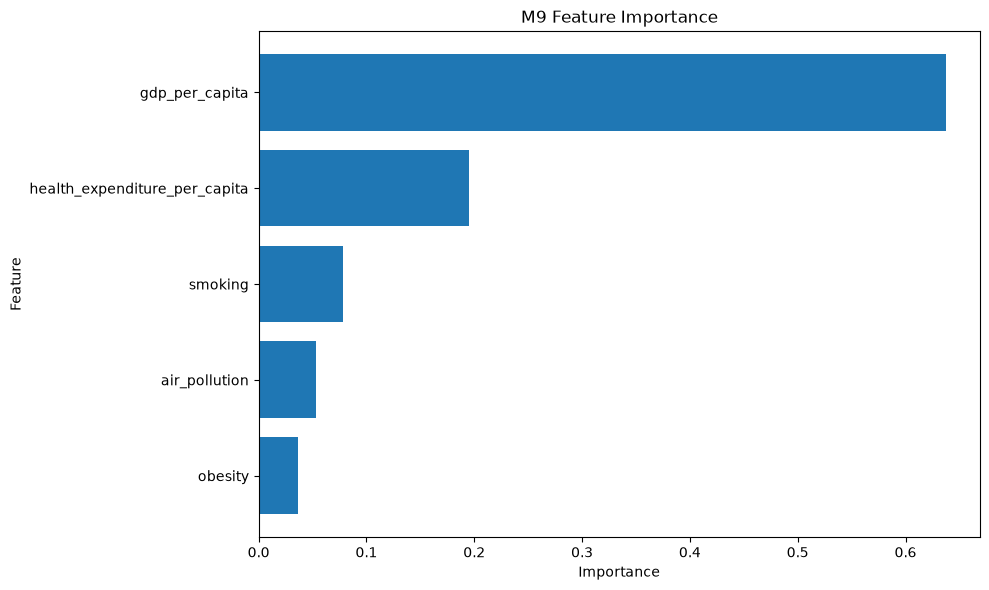

In [46]:
plt.figure(figsize=(10, 6))

m9_importance_plot = m9_importance.sort_values("Importance", ascending=True)

plt.barh(
    m9_importance_plot["Feature"],
    m9_importance_plot["Importance"]
)

plt.title("M9 Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In M9, GDP per capita remains the dominant predictor.

Health expenditure per capita is the second most important variable, suggesting that absolute healthcare spending is more informative than healthcare spending as a percentage of GDP in the final model.

Among lifestyle factors, smoking prevalence contributes more than obesity prevalence.

Air pollution provides additional environmental information, although its contribution is smaller than GDP per capita and health expenditure per capita.

## 11. Relative vs Absolute Healthcare Spending

M8 and M9 have the same structure except for the healthcare spending measure.

- **M8** uses health expenditure as a percentage of GDP.
- **M9** uses health expenditure per capita.

This comparison helps evaluate whether relative or absolute healthcare spending is more informative in the final model structure.

In [47]:
m8_m9_importance = feature_importance_audit[
    feature_importance_audit["Model_ID"].isin(["M8", "M9"])
].copy()

m8_m9_pivot = m8_m9_importance.pivot(
    index="Feature",
    columns="Model_ID",
    values="Importance"
).fillna(0)

m8_m9_pivot

Model_ID,M8,M9
Feature,,
air_pollution,0.050395,0.052813
gdp_per_capita,0.776974,0.637233
health_expenditure,0.059970,0.000000
health_expenditure_per_capita,0.000000,0.195331
obesity,0.037460,0.036783
smoking,0.075201,0.077840


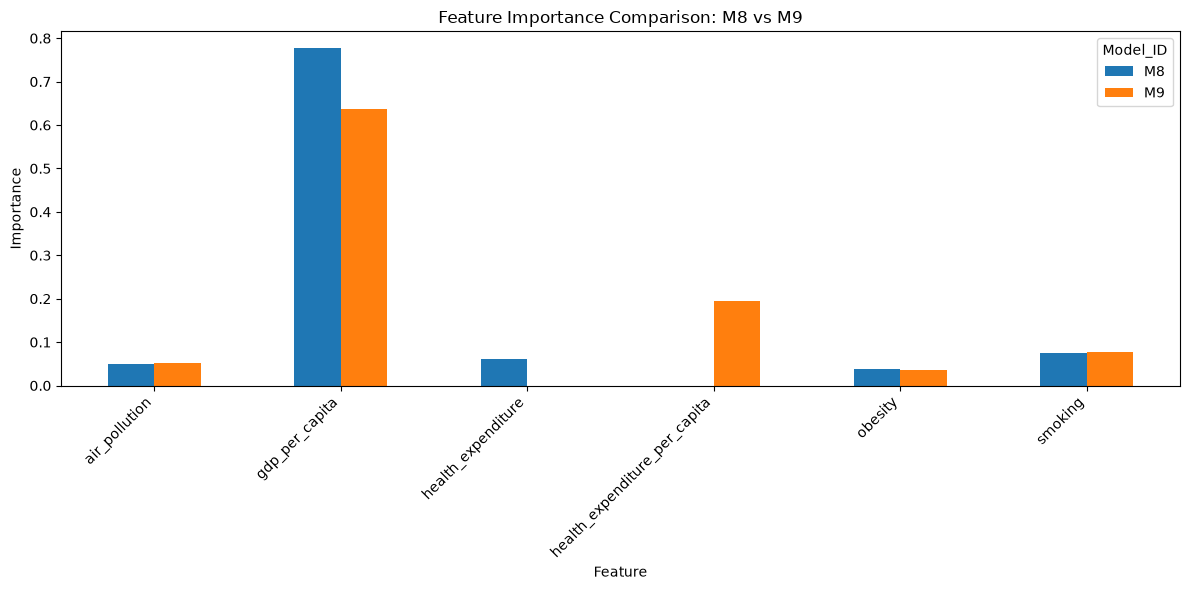

In [48]:
m8_m9_pivot.plot(kind="bar", figsize=(12, 6))

plt.title("Feature Importance Comparison: M8 vs M9")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

The comparison between M8 and M9 shows that replacing health expenditure as a percentage of GDP with health expenditure per capita improves model performance.

This suggests that absolute healthcare spending per person provides more useful predictive information than relative healthcare spending in the final model.

## 12. Model Performance Visualizations

The following charts summarize model performance across all tested models.

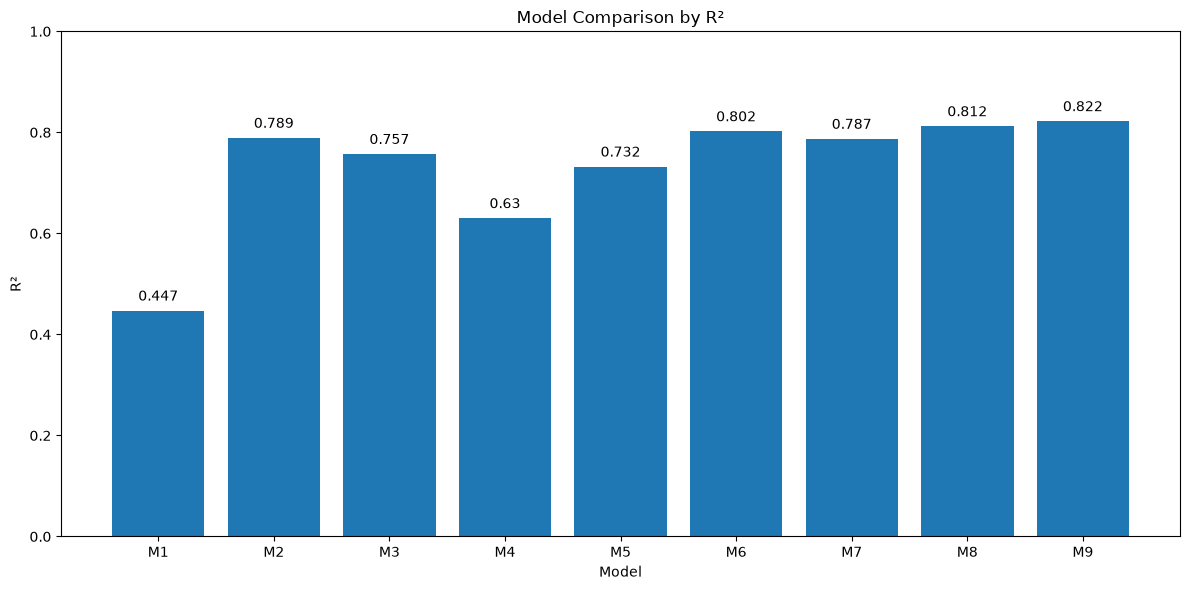

In [49]:
plt.figure(figsize=(12, 6))

plt.bar(
    model_audit["Model_ID"],
    model_audit["R_squared"]
)

plt.title("Model Comparison by R²")
plt.xlabel("Model")
plt.ylabel("R²")
plt.ylim(0, 1)

for i, value in enumerate(model_audit["R_squared"]):
    plt.text(i, value + 0.02, str(round(value, 3)), ha="center")

plt.tight_layout()
plt.show()

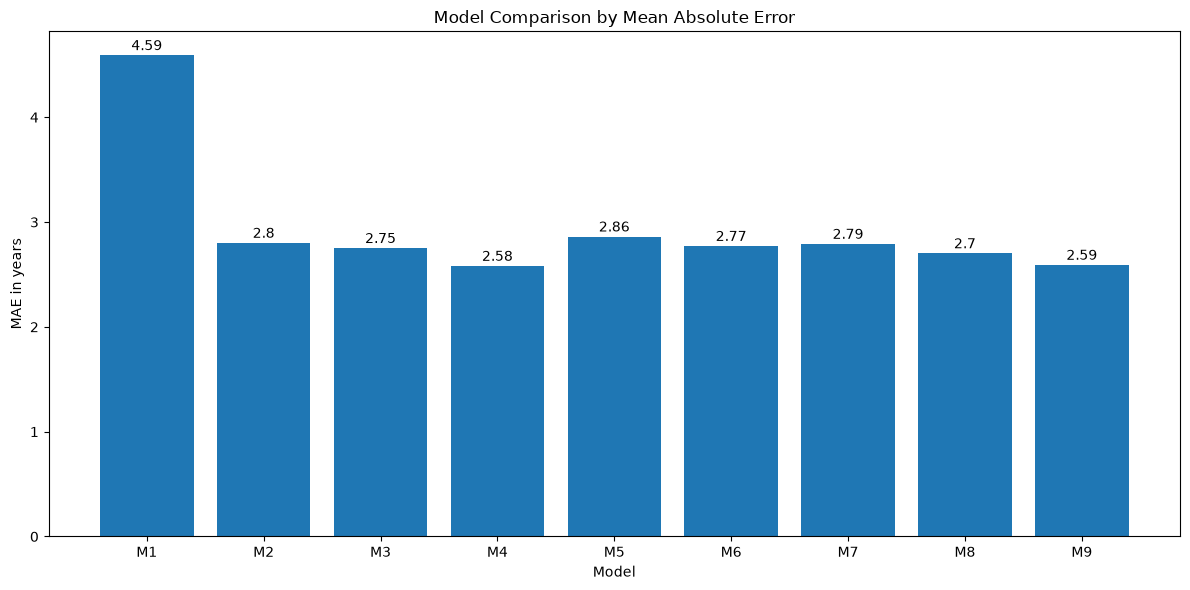

In [50]:
plt.figure(figsize=(12, 6))

plt.bar(
    model_audit["Model_ID"],
    model_audit["MAE_years"]
)

plt.title("Model Comparison by Mean Absolute Error")
plt.xlabel("Model")
plt.ylabel("MAE in years")

for i, value in enumerate(model_audit["MAE_years"]):
    plt.text(i, value + 0.05, str(round(value, 2)), ha="center")

plt.tight_layout()
plt.show()

The model comparison confirms that M9 achieves the highest R².

Although M4 has a slightly lower MAE, it uses a much smaller sample and has lower explanatory power.

M9 is therefore selected as the final model because it provides the strongest overall balance between explanatory performance, predictive accuracy, sample size and interpretability.

## 13. Final Audit Summary

The final audit summarizes the main consistency checks performed before drawing conclusions.

In [51]:
audit_summary = {
    "base_dataset_rows": len(base_dataset),
    "final_model_dataset_rows": len(final_model_dataset),
    "base_potential_aggregates": len(base_aggregate_check),
    "final_potential_aggregates": len(final_aggregate_check),
    "final_missing_values_total": int(final_model_dataset.isna().sum().sum()),
    "model_count": len(model_audit),
    "rf_model_count": len(rf_performance_audit),
    "best_model_by_r2": model_audit.sort_values("R_squared", ascending=False).iloc[0]["Model_ID"],
    "best_r2": model_audit.sort_values("R_squared", ascending=False).iloc[0]["R_squared"],
    "best_model_by_mae": model_audit.sort_values("MAE_years", ascending=True).iloc[0]["Model_ID"],
    "best_mae": model_audit.sort_values("MAE_years", ascending=True).iloc[0]["MAE_years"],
    "m9_importance_sum": round(
        feature_importance_audit[
            feature_importance_audit["Model_ID"] == "M9"
        ]["Importance"].sum(),
        6
    )
}

audit_summary

{'base_dataset_rows': 212,
 'final_model_dataset_rows': 155,
 'base_potential_aggregates': 10,
 'final_potential_aggregates': 0,
 'final_missing_values_total': 0,
 'model_count': 9,
 'rf_model_count': 7,
 'best_model_by_r2': 'M9',
 'best_r2': np.float64(0.822),
 'best_model_by_mae': 'M4',
 'best_mae': np.float64(2.58),
 'm9_importance_sum': np.float64(1.0)}

## 14. Final Conclusions

This section will be completed after reviewing the final results and macro-category interpretation.

The final conclusions will summarize:

- the role of economic factors;
- the role of healthcare spending;
- the role of lifestyle variables;
- the role of environmental exposure;
- the role and limitation of social indicators;
- why M9 is selected as the final model;
- limitations of the analysis;
- possible future improvements.

The final conclusion will be written after comparing the technical results with the broader interpretation of the project.